In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/System-Threat-Forecaster/sample_submission.csv
/kaggle/input/System-Threat-Forecaster/train.csv
/kaggle/input/System-Threat-Forecaster/test.csv
/kaggle/input/pictures/Screenshot 2025-03-20 160633.png
/kaggle/input/pictures/Screenshot 2025-03-20 160506.png


**Loading Datset**

In [2]:
train = pd.read_csv('/kaggle/input/System-Threat-Forecaster/train.csv')
test = pd.read_csv('/kaggle/input/System-Threat-Forecaster/test.csv')

*****Splitting the dataset into training and evaluation set*******

In [3]:
from sklearn.model_selection import train_test_split
y = train['target']
X = train.drop(columns = ['target'])
X_train,X_eval,y_train,y_eval = train_test_split(X,y,test_size = 0.2,random_state = 42)


In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 75 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   MachineID                           10000 non-null  object 
 1   ProductName                         10000 non-null  object 
 2   EngineVersion                       10000 non-null  object 
 3   AppVersion                          10000 non-null  object 
 4   SignatureVersion                    10000 non-null  object 
 5   IsBetaUser                          10000 non-null  int64  
 6   RealTimeProtectionState             9991 non-null   float64
 7   IsPassiveModeEnabled                10000 non-null  int64  
 8   AntivirusConfigID                   9998 non-null   float64
 9   NumAntivirusProductsInstalled       9998 non-null   float64
 10  NumAntivirusProductsEnabled         9998 non-null   float64
 11  HasTpm                              10000 

**Finding the important features in the dataset using random forest model**

<ipython-input-5-281695ac46db>:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(X_train[col].mode()[0], inplace=True)  # Use mode for categorical-like columns
<ipython-input-5-281695ac46db>:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

Selected 32 features based on dynamic thresholding:
['DateAS', 'SignatureVersion', 'MachineID', 'CityID', 'SystemVolumeCapacityMB', 'FirmwareVersionID', 'OEMModelID', 'ProcessorModelID', 'CountryID', 'GeoRegionID', 'LocaleEnglishNameID', 'PrimaryDisplayDiagonalInches', 'AntivirusConfigID', 'OEMNameID', 'OSBuildRevisionOnly', 'NumericOSVersion', 'PrimaryDiskCapacityMB', 'DateOS', 'RegionIdentifier', 'OSInstallType', 'OSInstallLanguageID', 'OSUILocaleID', 'FirmwareManufacturerID', 'TotalPhysicalRAMMB', 'NumAntivirusProductsInstalled', 'AppVersion', 'PrimaryDisplayResolutionHorizontal', 'InternalBatteryNumberOfCharges', 'PrimaryDisplayResolutionVertical', 'OSBuildLab', 'ChassisType', 'AutoUpdateOptionsName']


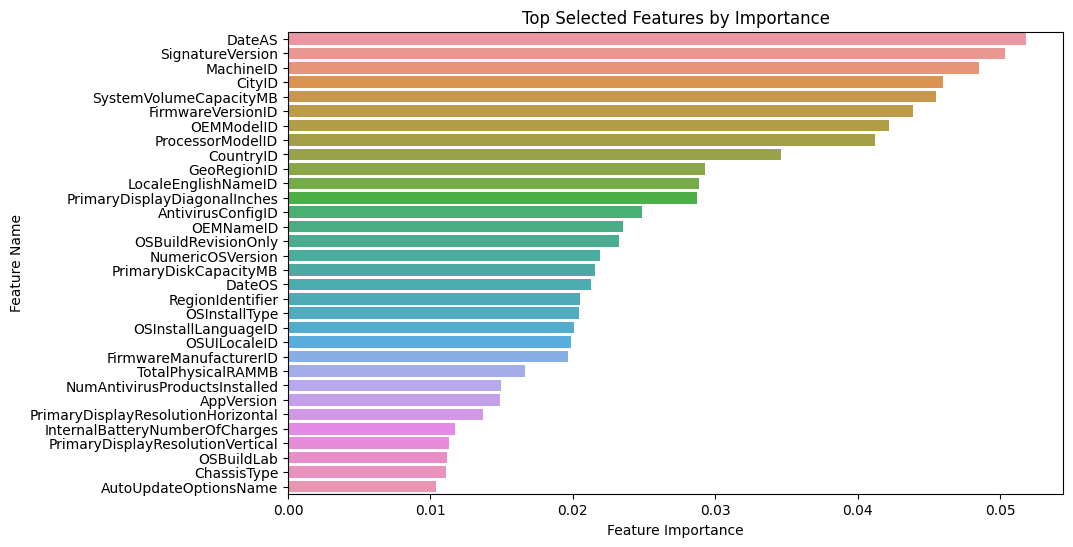

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Create a copy of X_train before making changes
X_train_original = X_train.copy()

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply Label Encoding to categorical features
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))  # Convert to string before encoding

# Convert all columns to float
X_train = X_train.apply(pd.to_numeric, errors='coerce')

# Handle missing values intelligently
for col in X_train.columns:
    if X_train[col].isnull().sum() > 0:  # If missing values exist
        if X_train[col].nunique() > 10:  # If it's likely a numerical column
            X_train[col].fillna(X_train[col].median(), inplace=True)  # Use median for numerical columns
        else:
            X_train[col].fillna(X_train[col].mode()[0], inplace=True)  # Use mode for categorical-like columns

# Ensure target variable is numeric
if y_train.dtype == 'object':  
    le_target = LabelEncoder()
    y_train = le_target.fit_transform(y_train)

# Convert target to numeric if needed
y_train = pd.to_numeric(y_train, errors='coerce')

# Check if any remaining non-numeric values exist
if X_train.isnull().sum().sum() > 0 or y_train.isnull().sum() > 0:
    raise ValueError("Some columns still contain non-numeric values. Check data preprocessing.")

# Initialize Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train)  # Should work now

# Get feature importance scores
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

# Sort by importance
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)

# Select features based on importance
threshold = 0.01 * feature_importances["Importance"].sum()  # Features contributing at least 1%
selected_features = feature_importances[feature_importances["Importance"] >= threshold]["Feature"].tolist()

# Limit the number of selected features
num_features_to_select = max(20, min(len(selected_features), 50))
top_features = feature_importances.head(num_features_to_select)["Feature"].tolist()

# Create new dataframe with selected features
X_train_selected = X_train[top_features]

# Display selected features
print(f"Selected {len(top_features)} features based on dynamic thresholding:")
print(top_features)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances["Importance"][:len(top_features)], y=feature_importances["Feature"][:len(top_features)])
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Top Selected Features by Importance")
plt.show()


****Creating the new training and evaluation containing the top 32 features****

In [6]:
X_train_new = X_train_original[top_features]
X_eval_new = X_eval[top_features]
test = test[top_features]
# Drop 'MachineId' column from all datasets
X_train_new = X_train_new.drop(columns=['MachineID'], errors='ignore')
X_eval_new = X_eval_new.drop(columns=['MachineID'], errors='ignore')
test = test.drop(columns=['MachineID'], errors='ignore')

# Print to confirm the column is removed
print("Remaining columns in X_train_new:", X_train_new.columns)
print("Remaining columns in X_eval_new:", X_eval_new.columns)
print("Remaining columns in test:", test.columns)


Remaining columns in X_train_new: Index(['DateAS', 'SignatureVersion', 'CityID', 'SystemVolumeCapacityMB',
       'FirmwareVersionID', 'OEMModelID', 'ProcessorModelID', 'CountryID',
       'GeoRegionID', 'LocaleEnglishNameID', 'PrimaryDisplayDiagonalInches',
       'AntivirusConfigID', 'OEMNameID', 'OSBuildRevisionOnly',
       'NumericOSVersion', 'PrimaryDiskCapacityMB', 'DateOS',
       'RegionIdentifier', 'OSInstallType', 'OSInstallLanguageID',
       'OSUILocaleID', 'FirmwareManufacturerID', 'TotalPhysicalRAMMB',
       'NumAntivirusProductsInstalled', 'AppVersion',
       'PrimaryDisplayResolutionHorizontal', 'InternalBatteryNumberOfCharges',
       'PrimaryDisplayResolutionVertical', 'OSBuildLab', 'ChassisType',
       'AutoUpdateOptionsName'],
      dtype='object')
Remaining columns in X_eval_new: Index(['DateAS', 'SignatureVersion', 'CityID', 'SystemVolumeCapacityMB',
       'FirmwareVersionID', 'OEMModelID', 'ProcessorModelID', 'CountryID',
       'GeoRegionID', 'LocaleEnglish

In [7]:
X_train_new.describe()

,CityID,SystemVolumeCapacityMB,FirmwareVersionID,OEMModelID,ProcessorModelID,CountryID,GeoRegionID,LocaleEnglishNameID,PrimaryDisplayDiagonalInches,AntivirusConfigID,...,PrimaryDiskCapacityMB,RegionIdentifier,OSInstallLanguageID,OSUILocaleID,FirmwareManufacturerID,TotalPhysicalRAMMB,NumAntivirusProductsInstalled,PrimaryDisplayResolutionHorizontal,InternalBatteryNumberOfCharges,PrimaryDisplayResolutionVertical
count,79518.000000,7.991700e+04,79733.000000,79820.000000,79932.000000,80000.000000,80000.000000,80000.0000,79941.000000,79940.000000,...,7.991700e+04,79540.000000,79903.000000,80000.000000,79700.000000,79881.000000,79940.000000,79941.000000,7.959700e+04,79941.000000
mean,81039.824832,3.815641e+05,32955.907742,238856.538173,2366.609143,108.305075,170.118700,122.6620,16.705363,48003.193670,...,5.148722e+05,7.866621,14.529592,60.079862,402.542949,6127.097320,1.325744,1551.930649,1.114953e+09,898.235661
std,49024.031159,3.246531e+05,21157.551577,71641.629714,837.720334,63.152735,89.152577,69.2456,6.059430,13763.965001,...,3.520998e+05,4.567209,10.151729,44.766221,221.291716,4882.813703,0.520074,364.280414,1.882979e+09,213.952989
min,7.000000,1.088000e+04,121.000000,22.000000,3.000000,1.000000,1.000000,1.0000,5.300000,39.000000,...,1.443200e+04,1.000000,1.000000,5.000000,56.000000,512.000000,1.000000,600.000000,0.000000e+00,480.000000
25%,36410.000000,1.208410e+05,13153.000000,189586.000000,1998.000000,51.000000,89.000000,74.0000,13.900000,49480.000000,...,2.441980e+05,3.000000,8.000000,31.000000,142.000000,4096.000000,1.000000,1366.000000,0.000000e+00,768.000000
50%,82373.000000,2.554490e+05,33066.000000,246566.000000,2500.000000,97.000000,181.000000,88.0000,15.500000,53447.000000,...,4.769400e+05,10.000000,9.000000,34.000000,500.000000,4096.000000,1.000000,1366.000000,0.000000e+00,768.000000
75%,123635.000000,4.761020e+05,52370.000000,302784.750000,2865.000000,162.000000,267.000000,182.0000,17.200000,53447.000000,...,9.538690e+05,11.000000,20.000000,83.000000,556.000000,8192.000000,2.000000,1920.000000,4.294967e+09,1080.000000
max,167946.000000,6.630319e+06,72091.000000,345324.000000,4478.000000,222.000000,296.000000,283.0000,142.000000,70486.000000,...,7.630885e+06,15.000000,39.000000,162.000000,1083.000000,262144.000000,5.000000,7680.000000,4.294967e+09,3840.000000


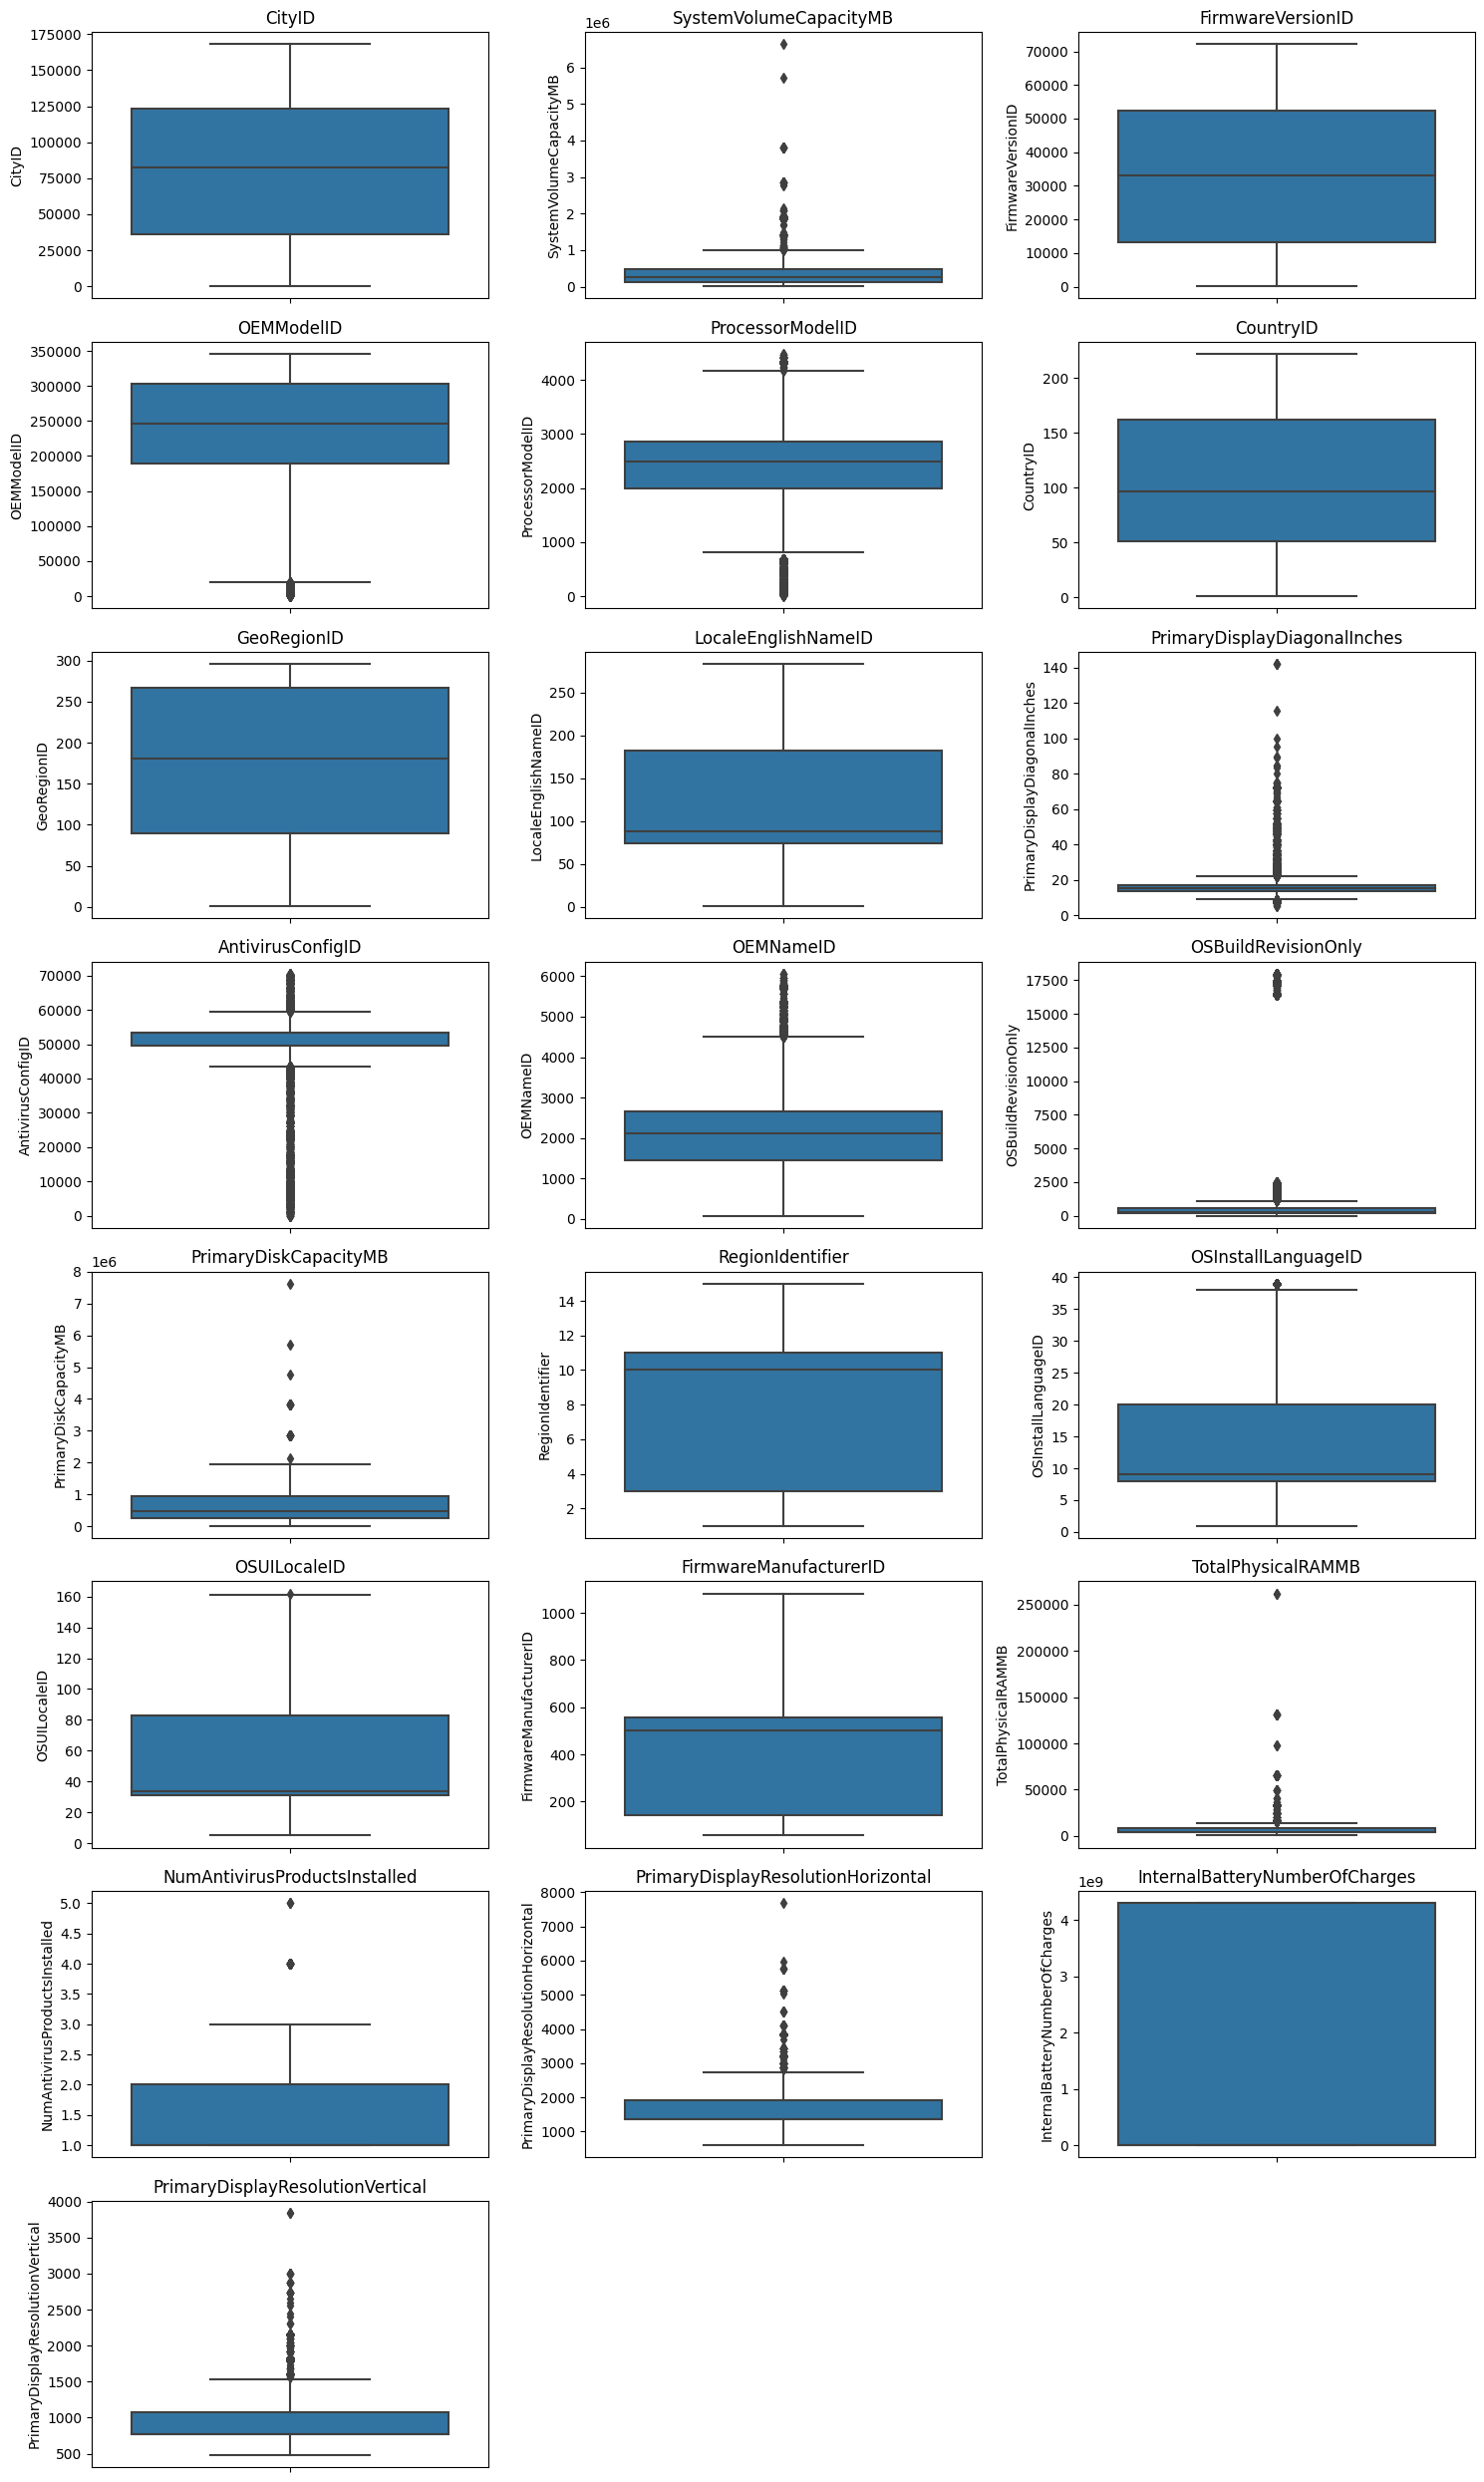

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(15, 25))
# Selecting numeric columns only
numeric_cols = X_train_new.select_dtypes(include=['number'])
# Plot individual box plots for each numeric column
for i, col in enumerate(numeric_cols.columns):
    plt.subplot(len(numeric_cols.columns) // 3 + 1, 3, i + 1)  # Arrange in grid layout
    sns.boxplot(y=numeric_cols[col])
    plt.title(col)

plt.tight_layout()  # Adjust layout for better readability
plt.show()


# Key Observations from the Box Plots

**Presence of Outliers:**

Many columns, such as S**ystemVolumeCapacityMB, ProcessorModelID, PrimaryDiskCapacityMB, and PrimaryDisplayDiagonalInches, have extreme outliers.**
These outliers could indicate 
erroneous data entries, rare cases, or genuine variations.Highly Skewed Distributions:


**Some features, like SystemVolumeCapacityMB, PrimaryDiskCapacityMB, and TotalPhysicalRAMMB, have a high concentration of data points at lower values, with a few extreme values pulling the distribution.**
This suggests that most devices have smaller disk and RAM capacities, but some have significantly higher specs.
Categorical or Discrete Numeric Variables:

**Variables like CityID, CountryID, FirmwareVersionID, and OEMModelID** have box plots with a more **uniform distribution**.
**These might be categorical identifiers stored as numbers** rather than true numerical values.
Tightly Packed Distributions:

**Columns such as RegionIdentifier and OSInstallLanguageID** have a small range of values.
This suggests that most observations fall** within a narrow range**, possibly due to limited available choices.
Features with Near-Constant Values:

Some box plots are almost **flat, meaning there is low variance in those features.**
These may not contribute much to model predictions and might be candidates for feature removal.

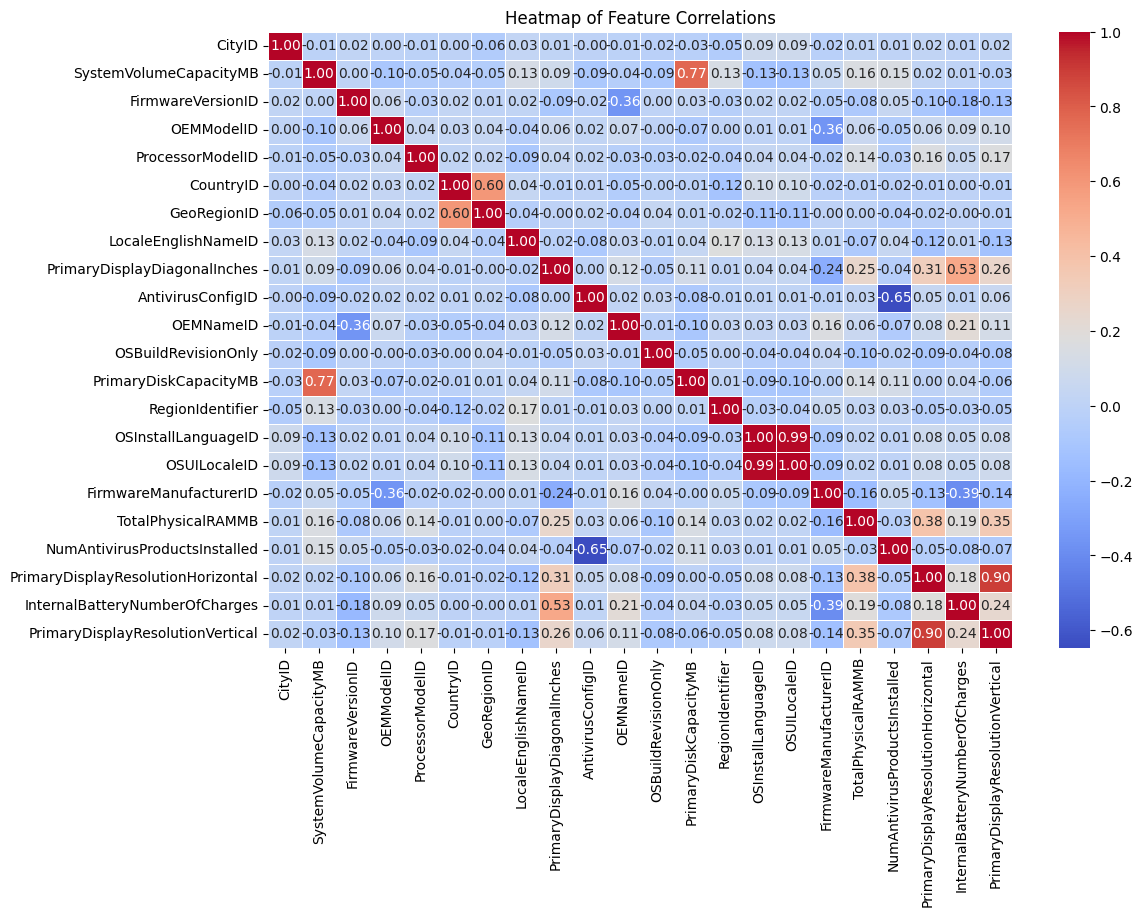

In [9]:
correlation_matrix = numeric_cols.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap of Feature Correlations")
plt.show()

Missing columns: set()


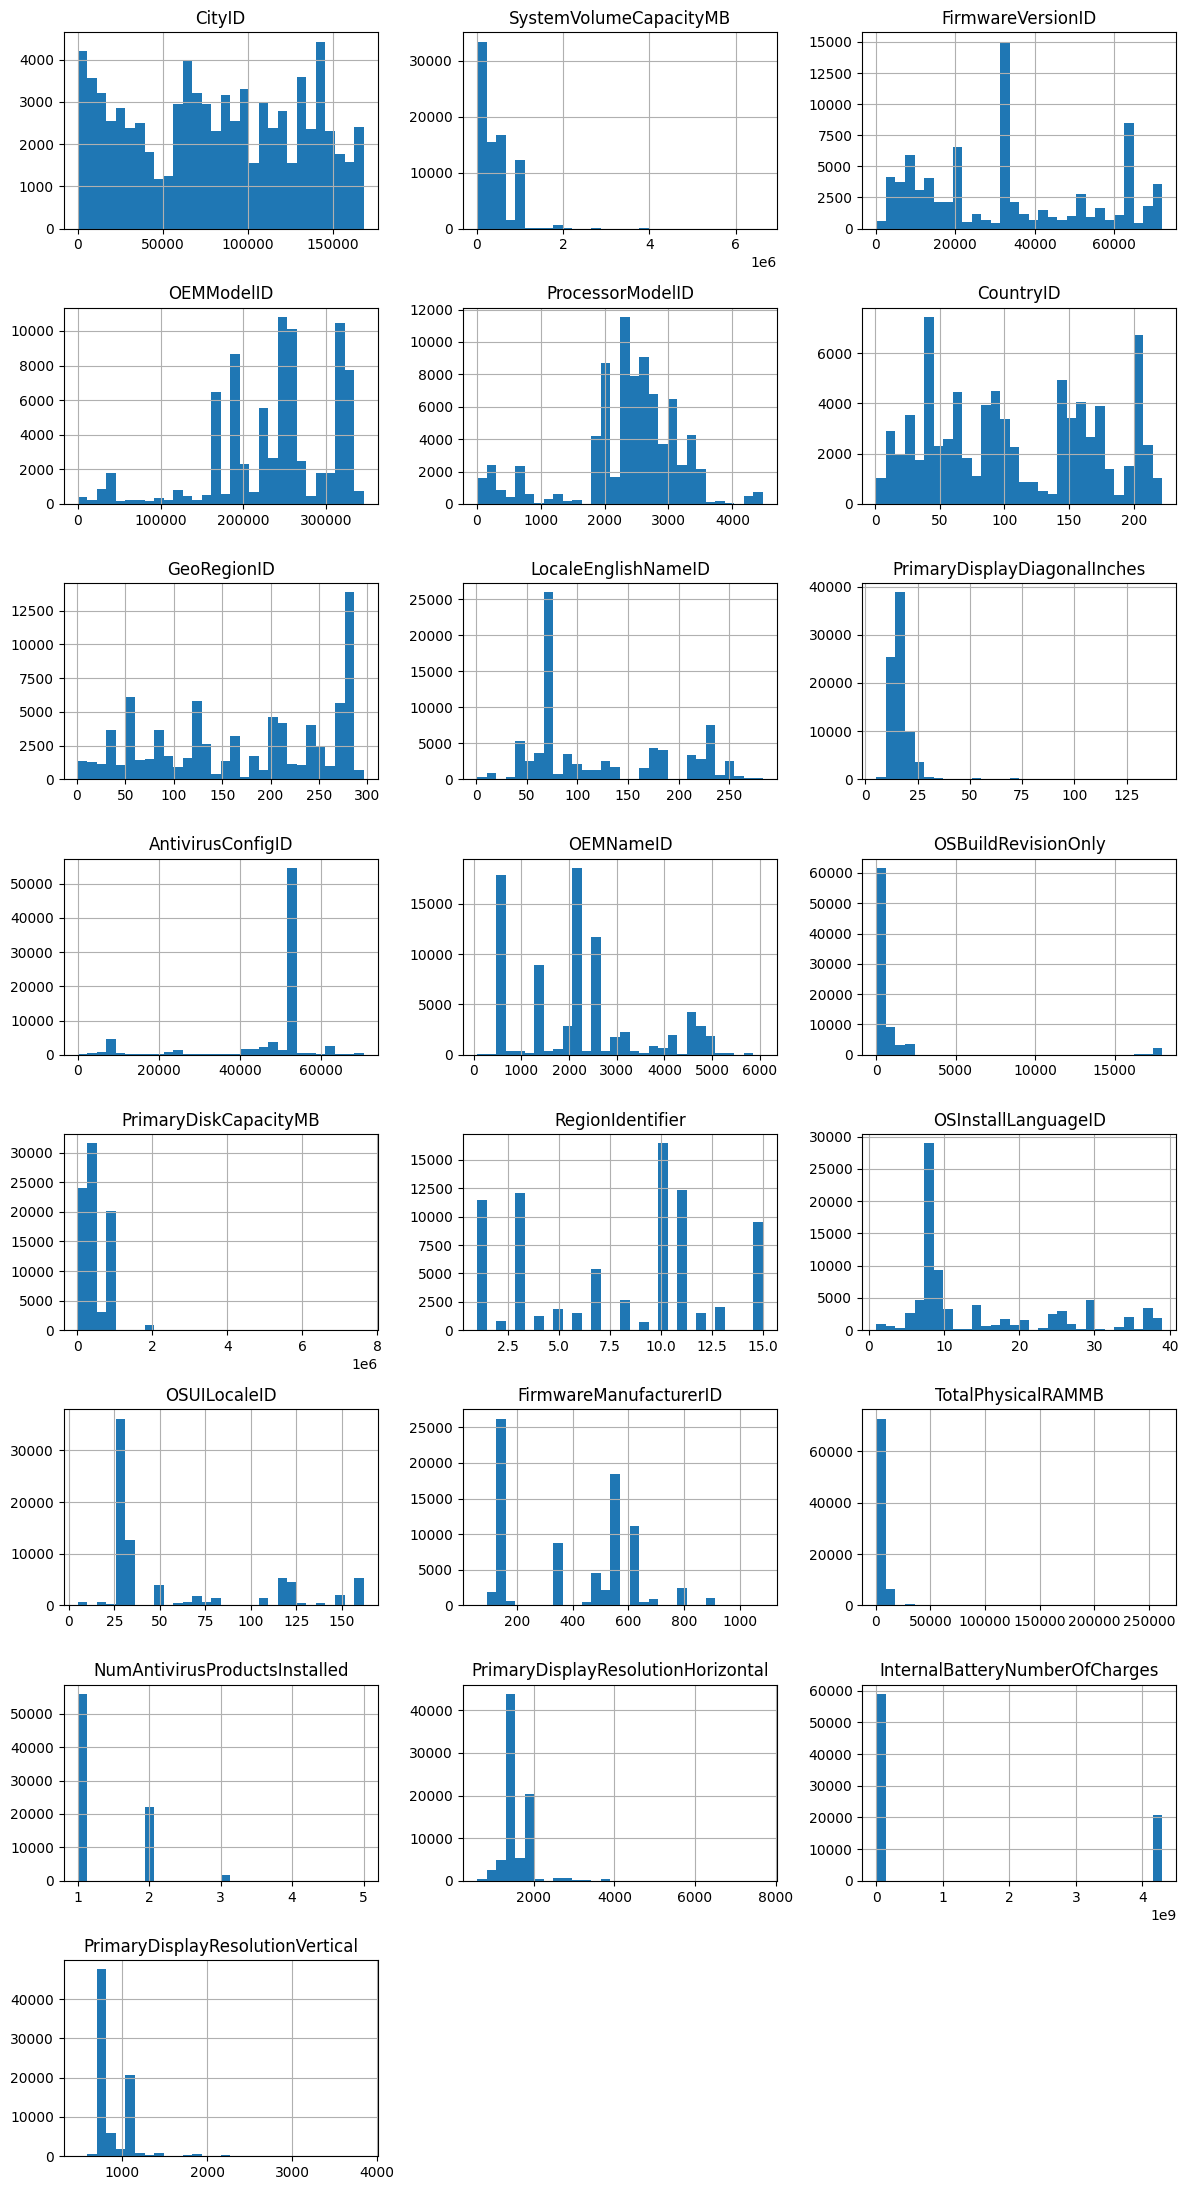

In [10]:
missing_cols = set(numeric_cols) - set(X_train_new.columns)
print("Missing columns:", missing_cols)
numeric_cols = list(X_train_new.select_dtypes(include=['number']).columns)

num_cols = len(numeric_cols)
rows = (num_cols // 3) + 1
cols = min(3, num_cols)  # Ensure no more columns than needed

X_train_new[numeric_cols].hist(figsize=(12, 22), bins=30, layout=(rows, cols))
plt.tight_layout()
plt.show()



# The figure consists of multiple histograms representing the distribution of various numeric features in the dataset. Here’s an intelligent summary covering key aspects:

1.** Skewed Distributions & Outliers # **
Highly Right-Skewed:

**SystemVolumeCapacityMB**, **PrimaryDiskCapacityMB**, **TotalPhysicalRAMMB**, **InternalBatteryNumberOfCharges** # show long tails, #* **indicating that most values are concentrated on the lower end, with a few extreme values.***
These outliers could impact modeling and may need transformation (e.g., log scaling) or capping.
Slightly Right-Skewed:

NumAntivirusProductsInstalled, PrimaryDisplayResolutionHorizontal, PrimaryDisplayResolutionVertical have most values clustered near the lower end but not as extreme as the above cases.

**2. Bimodal or Multimodal Distributions**
Features like **ProcessorModelID**, **FirmwareManufacturerID**, and **OEMModelID** exhibit multiple peaks, indicating distinct groups or categories within the numerical data.
This suggests a need for further segmentation or feature engineering (e.g., binning into categorical groups).

**3. Uniformly Distributed Features**
**CityID, CountryID, and GeoRegionID** appear to be fairly spread across the range, suggesting they may represent categorical identifiers rather than meaningful continuous values.

**4. Features with Dominant Categories**
**LocaleEnglishNameID, AntivirusConfigID, and OSUILocaleID** show strong peaks at specific values, meaning most data points belong to a few dominant categories.
These features might be better treated as categorical variables rather than continuous.

**5. Normally Distributed Features**
**ProcessorModelID** is one of the few features showing a bell-curve shape, suggesting it follows a normal distribution.

**6. Sparse Data Issues**
Some histograms, such as OSBuildRevisionOnly, have large gaps, indicating that these features contain sparse values or potential missing data.

# Identifying the Categorical and numerical features correctly as some of the categorical features are in numerical format

In [11]:
def identify_columns(df, percentage=0.05):  # 5% of total rows
    num_rows = df.shape[0]
    threshold = int(num_rows * percentage)  # Dynamic threshold

    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()

    # Identify categorical columns disguised as numerical
    potential_categoricals = [
        col for col in numeric_cols 
        if df[col].nunique() <= threshold or "ID" in col.upper()  # Check uniqueness & column name
    ]

    # Move them to categorical list
    for col in potential_categoricals:
        numeric_cols.remove(col)
        categorical_cols.append(col)

    return numeric_cols, categorical_cols

numeric_cols, categorical_cols = identify_columns(X_train_new, percentage=0.001)  # Adjust percentage if needed

print(f"Numerical Columns: {numeric_cols}")
print(f"Categorical Columns: {categorical_cols}")


Numerical Columns: ['SystemVolumeCapacityMB', 'PrimaryDisplayDiagonalInches', 'OSBuildRevisionOnly', 'PrimaryDiskCapacityMB', 'TotalPhysicalRAMMB', 'PrimaryDisplayResolutionHorizontal', 'InternalBatteryNumberOfCharges', 'PrimaryDisplayResolutionVertical']
Categorical Columns: ['DateAS', 'SignatureVersion', 'NumericOSVersion', 'DateOS', 'OSInstallType', 'AppVersion', 'OSBuildLab', 'ChassisType', 'AutoUpdateOptionsName', 'CityID', 'FirmwareVersionID', 'OEMModelID', 'ProcessorModelID', 'CountryID', 'GeoRegionID', 'LocaleEnglishNameID', 'AntivirusConfigID', 'OEMNameID', 'RegionIdentifier', 'OSInstallLanguageID', 'OSUILocaleID', 'FirmwareManufacturerID', 'NumAntivirusProductsInstalled']


# Visualising key statistics of categorical Columns


--- Statistics for DateAS ---
Total Values: 80000
Unique Categories (excluding NaN): 2542
Missing Values: 0


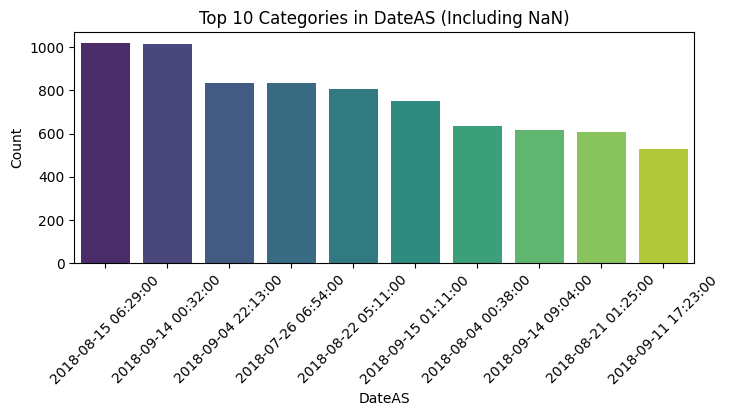


--- Statistics for SignatureVersion ---
Total Values: 80000
Unique Categories (excluding NaN): 2581
Missing Values: 0


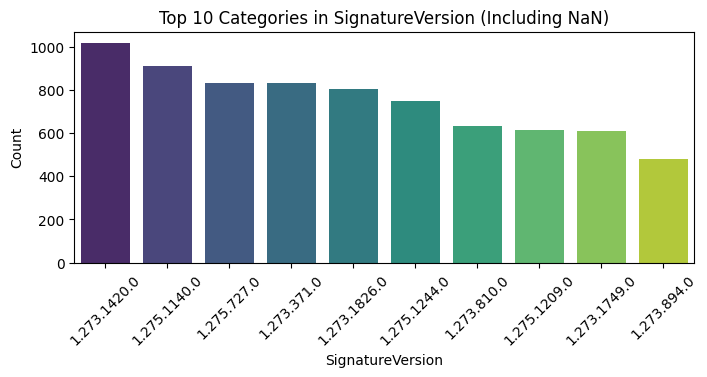


--- Statistics for NumericOSVersion ---
Total Values: 80000
Unique Categories (excluding NaN): 216
Missing Values: 0


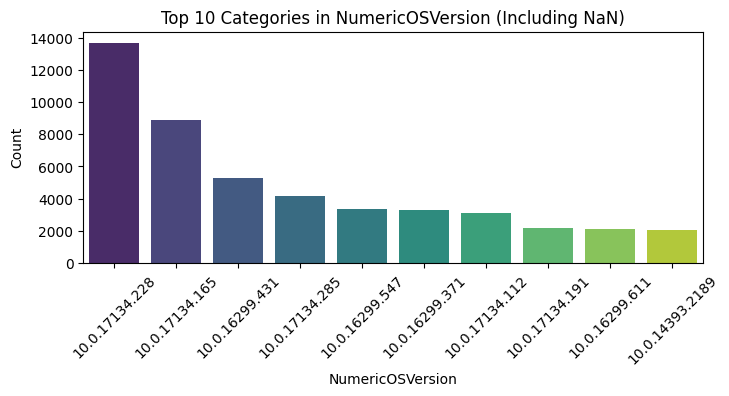


--- Statistics for DateOS ---
Total Values: 80000
Unique Categories (excluding NaN): 111
Missing Values: 20


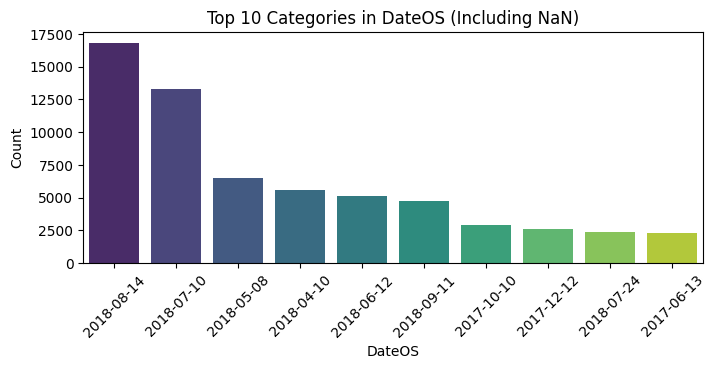


--- Statistics for OSInstallType ---
Total Values: 80000
Unique Categories (excluding NaN): 9
Missing Values: 0


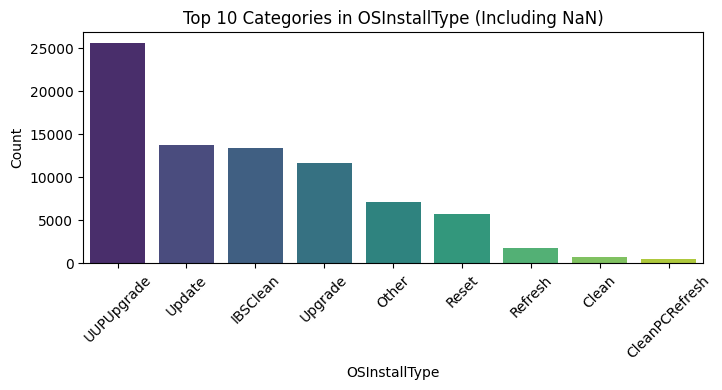


--- Statistics for AppVersion ---
Total Values: 80000
Unique Categories (excluding NaN): 69
Missing Values: 0


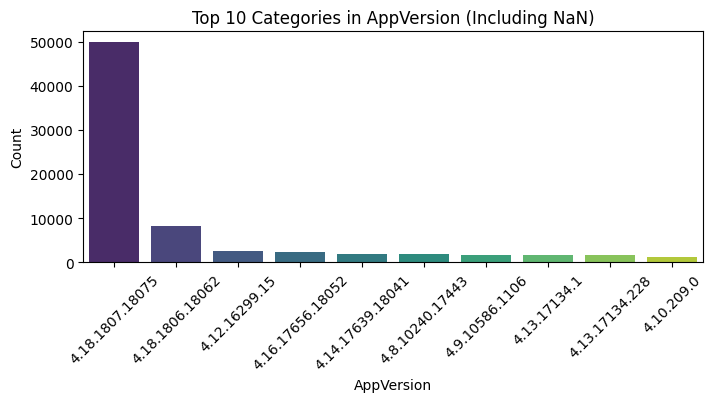


--- Statistics for OSBuildLab ---
Total Values: 80000
Unique Categories (excluding NaN): 274
Missing Values: 0


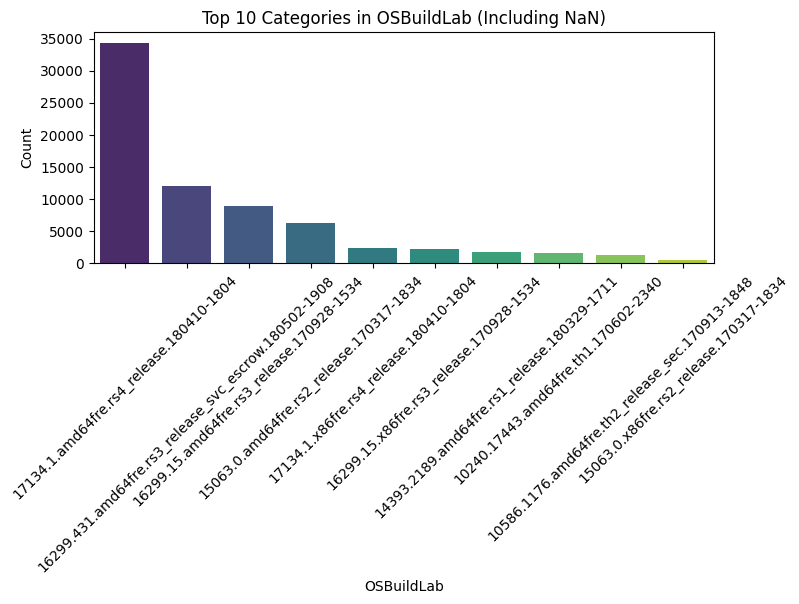


--- Statistics for ChassisType ---
Total Values: 80000
Unique Categories (excluding NaN): 27
Missing Values: 1


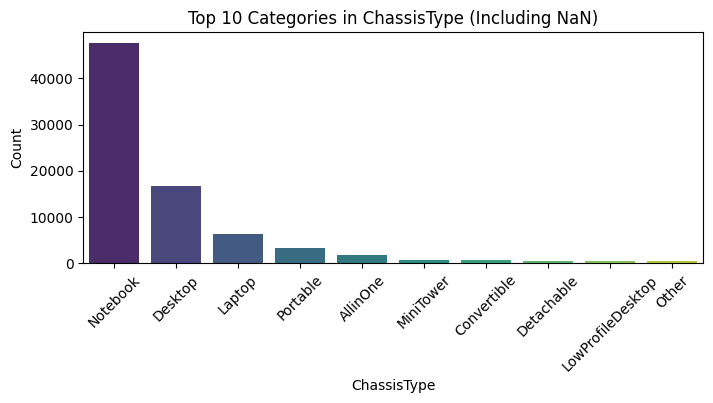


--- Statistics for AutoUpdateOptionsName ---
Total Values: 80000
Unique Categories (excluding NaN): 6
Missing Values: 0


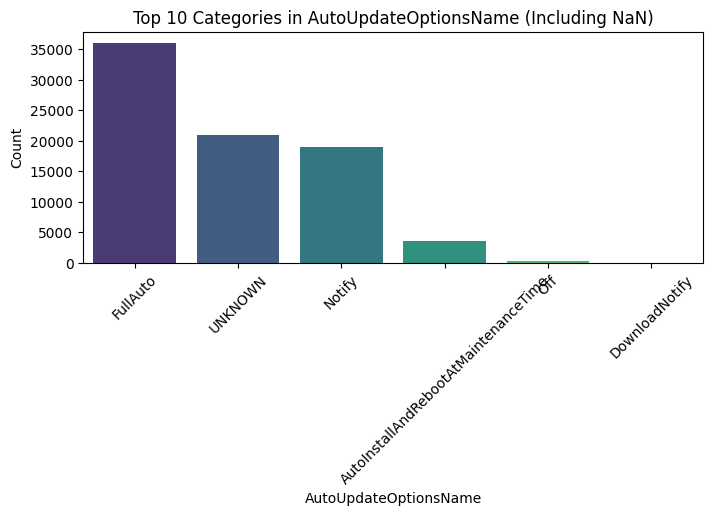


--- Statistics for CityID ---
Total Values: 80000
Unique Categories (excluding NaN): 14077
Missing Values: 482


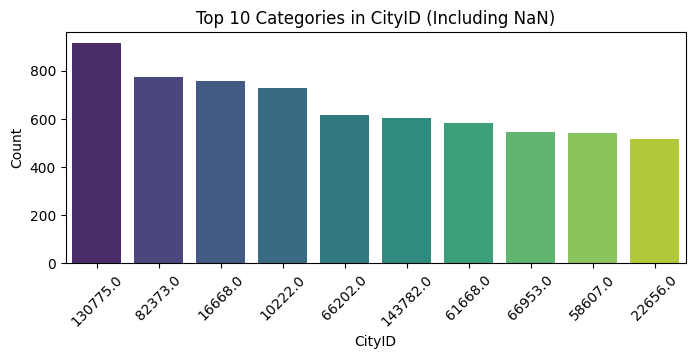


--- Statistics for FirmwareVersionID ---
Total Values: 80000
Unique Categories (excluding NaN): 11044
Missing Values: 267


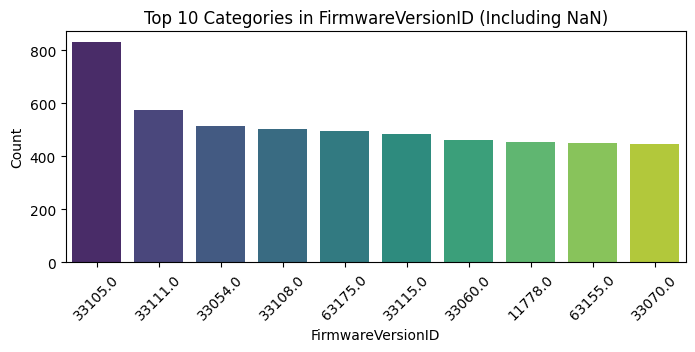


--- Statistics for OEMModelID ---
Total Values: 80000
Unique Categories (excluding NaN): 14045
Missing Values: 180


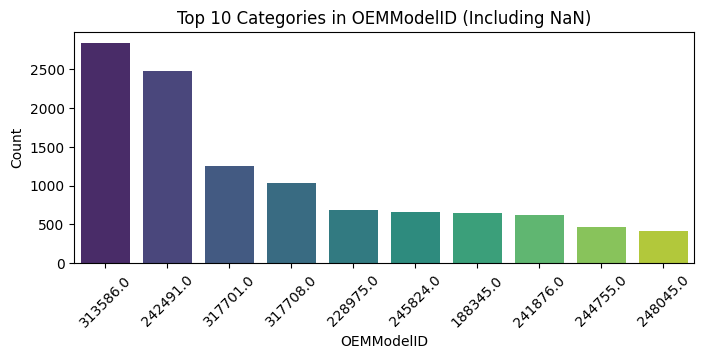


--- Statistics for ProcessorModelID ---
Total Values: 80000
Unique Categories (excluding NaN): 1576
Missing Values: 68


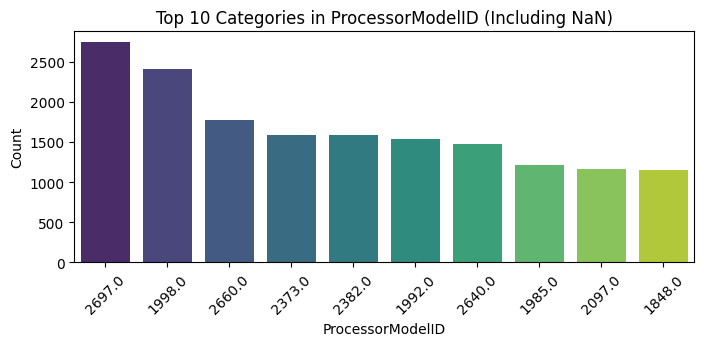


--- Statistics for CountryID ---
Total Values: 80000
Unique Categories (excluding NaN): 220
Missing Values: 0


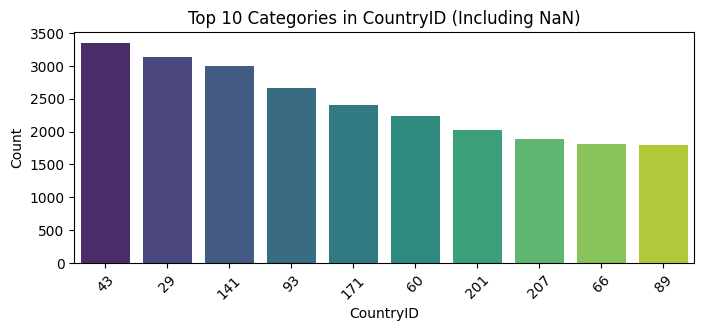


--- Statistics for GeoRegionID ---
Total Values: 80000
Unique Categories (excluding NaN): 231
Missing Values: 0


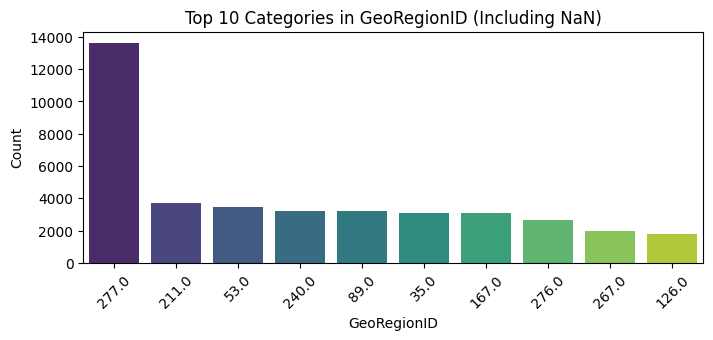


--- Statistics for LocaleEnglishNameID ---
Total Values: 80000
Unique Categories (excluding NaN): 180
Missing Values: 0


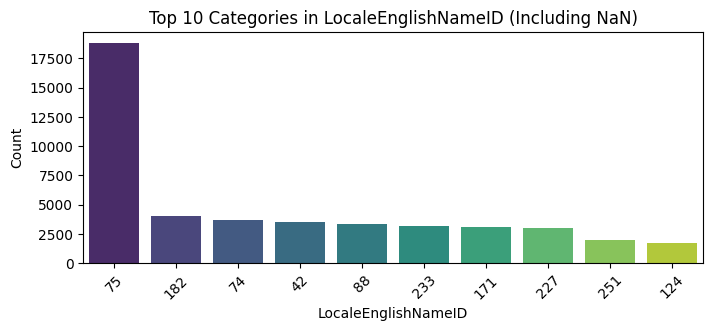


--- Statistics for AntivirusConfigID ---
Total Values: 80000
Unique Categories (excluding NaN): 1732
Missing Values: 60


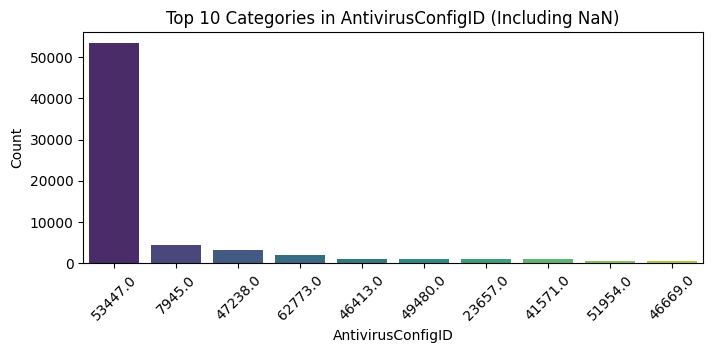


--- Statistics for OEMNameID ---
Total Values: 80000
Unique Categories (excluding NaN): 764
Missing Values: 166


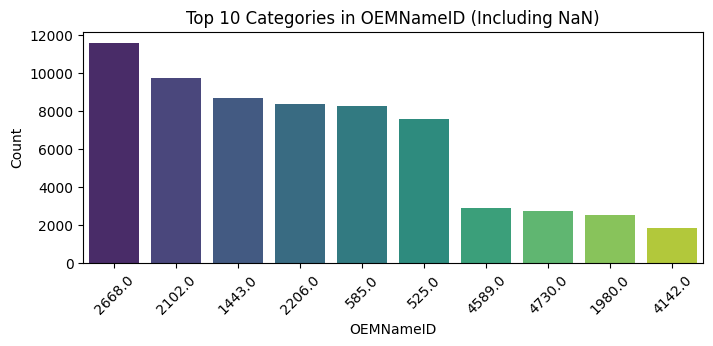


--- Statistics for RegionIdentifier ---
Total Values: 80000
Unique Categories (excluding NaN): 15
Missing Values: 460


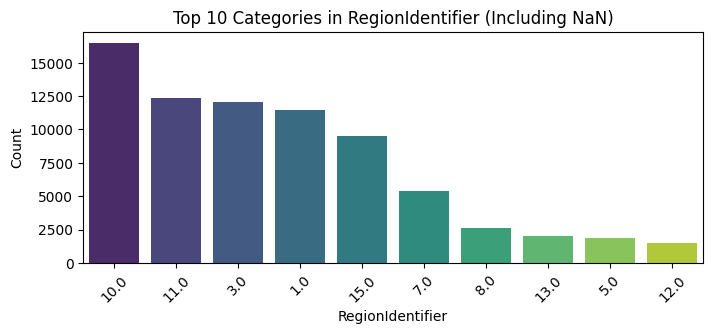


--- Statistics for OSInstallLanguageID ---
Total Values: 80000
Unique Categories (excluding NaN): 39
Missing Values: 97


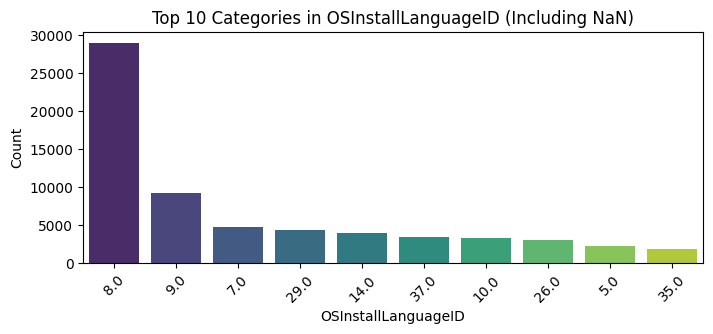


--- Statistics for OSUILocaleID ---
Total Values: 80000
Unique Categories (excluding NaN): 60
Missing Values: 0


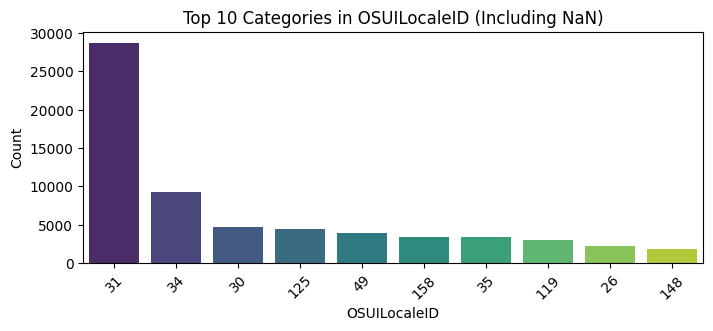


--- Statistics for FirmwareManufacturerID ---
Total Values: 80000
Unique Categories (excluding NaN): 155
Missing Values: 300


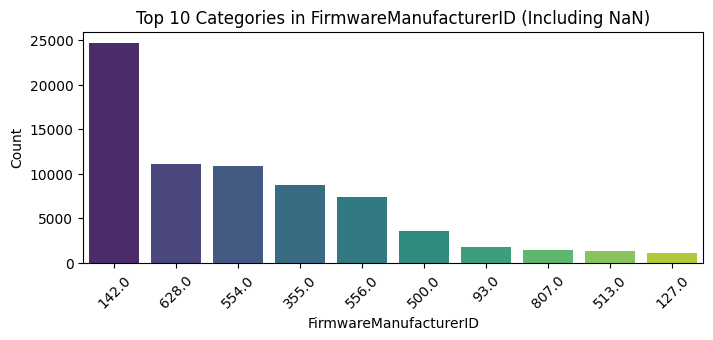


--- Statistics for NumAntivirusProductsInstalled ---
Total Values: 80000
Unique Categories (excluding NaN): 5
Missing Values: 60


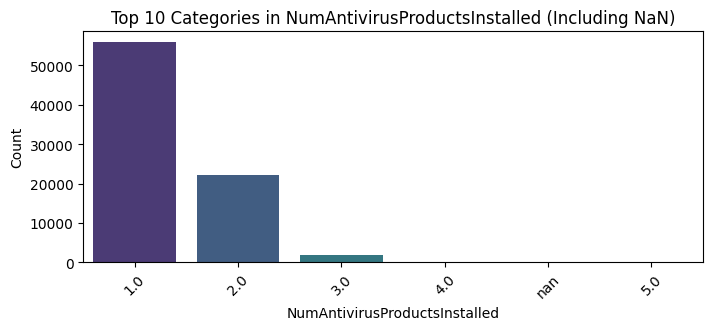

In [12]:


def visualize_categorical_stats(df, column, top_n=10):
    """Visualizes key statistics of a categorical (object) column, including missing values."""
    
    if column not in df.columns:
        print(f"Column '{column}' not found in DataFrame.")
        return

    # Count occurrences, including NaN as a category
    value_counts = df[column].value_counts(dropna=False)

    # Show missing values separately
    missing_values = df[column].isna().sum()
    total_values = len(df[column])
    
    print(f"Total Values: {total_values}")
    print(f"Unique Categories (excluding NaN): {df[column].nunique(dropna=True)}")
    print(f"Missing Values: {missing_values}")
    
    # Plot bar chart, including NaN as a separate bar
    plt.figure(figsize=(8, 3))
    sns.barplot(x=value_counts.head(top_n).index.astype(str), 
                y=value_counts.head(top_n).values, 
                palette='viridis')
    
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.title(f'Top {top_n} Categories in {column} (Including NaN)')
    plt.xticks(rotation=45)
    
    plt.show()


for col in categorical_cols:
    print(f"\n--- Statistics for {col} ---")
    visualize_categorical_stats(X_train_new, col)


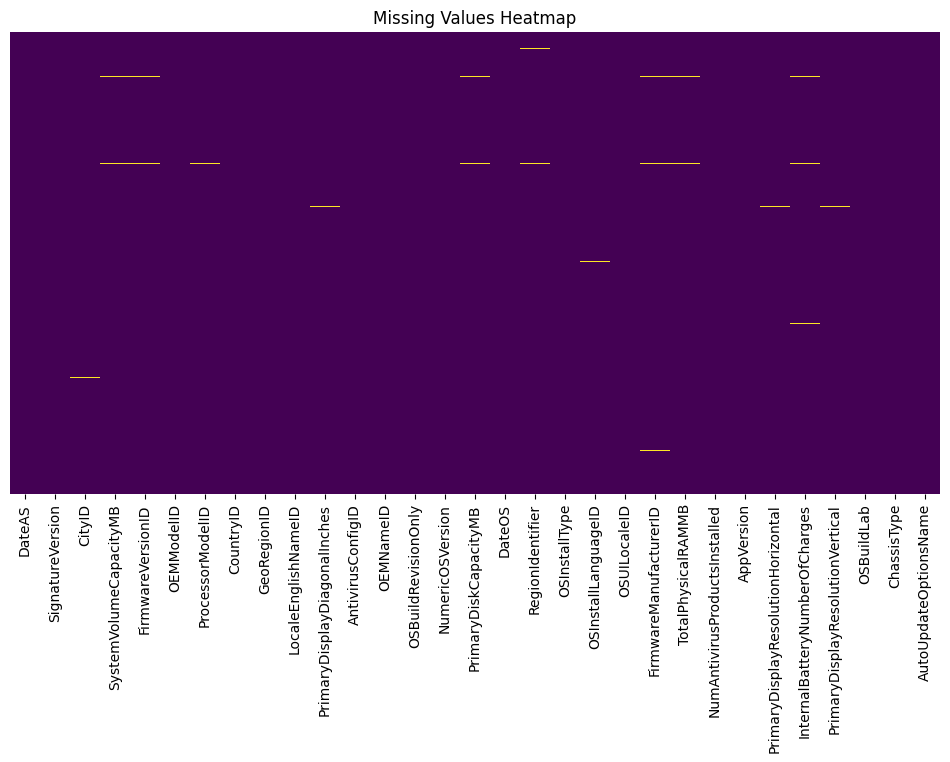

In [13]:
plt.figure(figsize=(12, 6))
sns.heatmap(X_train_new.isnull(), cmap="viridis", cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

**Key Conclusions from the Missing Values Heatmap:**
**Few Missing Values**: The dataset has very few missing values, **indicated by the sparse yellow lines on the dark background.**

**Scattered Missingness:** Missing values are scattered across multiple columns rather than being concentrated in specific areas.

**Columns with Missing Data**: Some columns like CityID, FirmwareVersionID, GeoRegionID, OSInstallLanguageID, and PrimaryDiskCapacityMB contain missing values.
**No Major Data Loss**: Since most of the dataset appears complete, missing data may not significantly impact model performance but still requires proper handling.
Next Steps: Depending on the missing values' proportion, imputation (e.g., mean/median/mode) or removal may be necessary.

# Imputing missing values with median for numerical columns and with mode for categorical columns

In [14]:


# List of columns to fill missing values with median
median_columns = [
    "NumAntivirusProductsInstalled","InternalBatteryNumberOfCharges", "PrimaryDisplayResolutionVertical", 
    "TotalPhysicalRAMMB", "PrimaryDiskCapacityMB", "OSBuildRevisionOnly", 
    "PrimaryDisplayDiagonalInches", "SystemVolumeCapacityMB"
]

# Function to handle missing and infinite values
def handle_missing_values(df):
    df = df.copy()  # Ensure the original DataFrame is not modified directly

    # Replace infinite values with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill missing values appropriately
    for col in df.columns:
        if df[col].isna().any():  # Check if the column has NaN values
            if col in median_columns:
                median_value = df[col].median()
                if not pd.isna(median_value):  # Ensure median is not NaN
                    df[col] = df[col].fillna(median_value)
            else:
                mode_value = df[col].mode()
                if not mode_value.empty:  # Ensure mode is not empty
                    df[col] = df[col].fillna(mode_value[0])

    return df

# Apply function to all datasets
X_train_new = handle_missing_values(X_train_new)
X_eval_new = handle_missing_values(X_eval_new)
test = handle_missing_values(test)

print("Missing and infinite values handled successfully!")


Missing and infinite values handled successfully!


In [15]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   DateAS                              10000 non-null  object 
 1   SignatureVersion                    10000 non-null  object 
 2   CityID                              10000 non-null  float64
 3   SystemVolumeCapacityMB              10000 non-null  float64
 4   FirmwareVersionID                   10000 non-null  float64
 5   OEMModelID                          10000 non-null  float64
 6   ProcessorModelID                    10000 non-null  float64
 7   CountryID                           10000 non-null  int64  
 8   GeoRegionID                         10000 non-null  float64
 9   LocaleEnglishNameID                 10000 non-null  int64  
 10  PrimaryDisplayDiagonalInches        10000 non-null  float64
 11  AntivirusConfigID                   10000 

# Feature engineering

In [16]:


# Split 'AppVersion' into multiple columns as strings
for df in [X_train_new, X_eval_new, test]:
    df[['AppVersion_1', 'AppVersion_2', 'AppVersion_3', 'AppVersion_4']] = (
        df['AppVersion'].str.split('.', expand=True).astype(str)
    )
    df.drop(columns=['AppVersion'], inplace=True)  # Drop the original column






# Encoding categorical columns with one hot encoding and label encoding columns with order is label encoded and without order is one hot encoded

In [17]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd


# Define categorical columns
one_hot_cols = ["DateAS", "SignatureVersion", "NumericOSVersion", "DateOS", "OSInstallType", "OSBuildLab", "AutoUpdateOptionsName"]
label_encoding_cols = ["CityID", "FirmwareVersionID", "OEMModelID", "ProcessorModelID", "CountryID", 
                       "GeoRegionID", "LocaleEnglishNameID", "AntivirusConfigID", "OEMNameID", 
                       "RegionIdentifier", "OSInstallLanguageID", "OSUILocaleID", "FirmwareManufacturerID", 
                        "PrimaryDisplayResolutionHorizontal", "ChassisType","AppVersion_4","AppVersion_3","AppVersion_2","AppVersion_1"]

# Step 1: Label Encoding for Ordered Categorical Columns
le_dict = {}  # Dictionary to store LabelEncoders for consistency

for col in label_encoding_cols:
    le = LabelEncoder()
    X_train_new[col] = le.fit_transform(X_train_new[col])  # Fit on training data
    
    # Use transform correctly and handle unseen categories in evaluation & test sets
    X_eval_new[col] = X_eval_new[col].apply(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    test[col] = test[col].apply(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    
    le_dict[col] = le  # Store encoder for consistency


# Step 2: One-Hot Encoding for Nominal Categorical Columns
X_train_new = pd.get_dummies(X_train_new, columns=one_hot_cols, drop_first=True)
X_eval_new = pd.get_dummies(X_eval_new, columns=one_hot_cols, drop_first=True)
test = pd.get_dummies(test, columns=one_hot_cols, drop_first=True)

# Step 3: Align One-Hot Encoded Columns for Consistency
X_train_new, X_eval_new = X_train_new.align(X_eval_new, join='left', axis=1, fill_value=0)
X_train_new, test = X_train_new.align(test, join='left', axis=1, fill_value=0)

In [18]:
X_train_new[median_columns] = X_train_new[median_columns].apply(pd.to_numeric, errors='coerce')
X_eval_new[median_columns] = X_eval_new[median_columns].apply(pd.to_numeric, errors='coerce')
test[median_columns] = test[median_columns].apply(pd.to_numeric, errors='coerce')


# Scaling Numerical Features

In [19]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform all datasets
X_train_new[median_columns] = scaler.fit_transform(X_train_new[median_columns])
X_eval_new[median_columns] = scaler.transform(X_eval_new[median_columns])  # Fixed variable name
test[median_columns] = scaler.transform(test[median_columns])



# Training the dataset with Xgboost and calculating the accuracy score

In [20]:
from sklearn.metrics import classification_report
import time
import numpy as np
from tqdm import tqdm
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Track start time
start_time = time.time()

# Initialize XGBoost classifier
xgb = XGBClassifier(
    n_estimators=100,   # Number of trees
    learning_rate=0.1,  # Step size shrinkage
    max_depth=6,        # Maximum depth of trees
    subsample=0.8,      # Fraction of training data used per tree
    colsample_bytree=0.8,  # Fraction of features used per tree
    random_state=42,
    use_label_encoder=False,  # Suppress warning
    eval_metric="logloss"     # Default evaluation metric
)

# Wrap the training process in tqdm to show progress
print("Training XGBoost Model...")
for i in tqdm(range(1, 101)):  # Simulate progress tracking
    if i == 1:
        xgb.fit(X_train_new, y_train)  # Train the model

# Make predictions on evaluation set
y_pred = xgb.predict(X_eval_new)

# Compute accuracy score
accuracy = accuracy_score(y_eval, y_pred)

# Print results
elapsed_time = time.time() - start_time
print(f"\n✅ Model Training Complete!")
print(f"📊 Accuracy on Evaluation Set: {accuracy:.4f}")
print(f"⏳ Time Elapsed: {elapsed_time:.2f} seconds")
print(classification_report(y_eval, y_pred))


Training XGBoost Model...


100%|██████████| 100/100 [01:32<00:00,  1.09it/s]



✅ Model Training Complete!
📊 Accuracy on Evaluation Set: 0.6166
⏳ Time Elapsed: 100.59 seconds
              precision    recall  f1-score   support

           0       0.63      0.55      0.59      9878
           1       0.61      0.68      0.64     10122

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.61     20000
weighted avg       0.62      0.62      0.61     20000



# Using Baysian Search CV for hypertuning the XGB model

In [22]:
import time
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import StratifiedKFold

# Define XGBoost Classifier
xgb_clf = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    tree_method='hist',  # Optimized for speed
    verbosity=0
)

# Define a speed-optimized hyperparameter search space
search_space = {
    'n_estimators': Integer(100, 500),  # Lower to speed up training
    'learning_rate': Real(0.05, 0.2, prior='log-uniform'),  # Avoid very low values
    'max_depth': Integer(3, 10),  # Control complexity
    'subsample': Real(0.6, 0.9),  # Moderate sampling for speed & accuracy
    'colsample_bytree': Real(0.6, 0.9),  # Avoid extreme values
    'gamma': Real(0, 5),  # Pruning
    'min_child_weight': Integer(1, 6),  # Regularization
    'reg_lambda': Real(0.01, 5, prior='log-uniform'),  # L2 regularization
    'reg_alpha': Real(0.01, 5, prior='log-uniform'),  # L1 regularization
}

# Initialize Bayesian Optimization with Cross-Validation
bayes_search = BayesSearchCV(
    estimator=xgb_clf,
    search_spaces=search_space,
    n_iter=20,  # Reduce iterations for speed
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,  # Use all CPUs
    verbose=2,
    random_state=42
)

# Start timer
start_time = time.time()

# Fit the model on training data
bayes_search.fit(X_train_new, y_train)

# End timer
end_time = time.time()

# Best parameters
print("Best Parameters:", bayes_search.best_params_)

#Predict on evaluation set
y_pred = bayes_search.best_estimator_.predict(X_eval_new)

# Calculate accuracy
accuracy = accuracy_score(y_eval, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_eval,y_pred))
 #Print time taken
print(f"Time Elapsed: {end_time - start_time:.2f} seconds")
y_pred_test = bayes_search.best_estimator_.predict(test)
print(y_pred_test)


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

# Training data on Random Classifier Model

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from tqdm import tqdm  # For progress tracking

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, verbose=1, n_jobs=-1)

# Fit the model on training data with tqdm progress bar
with tqdm(total=100, desc="Training Progress") as pbar:
    rf_model.fit(X_train_new, y_train)
    pbar.update(100)  # Update progress to 100% after training

# Predict on training and evaluation datasets
y_train_pred = rf_model.predict(X_train_new)
y_eval_pred = rf_model.predict(X_eval_new)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
eval_accuracy = accuracy_score(y_eval, y_eval_pred)

# Print results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Evaluation Accuracy: {eval_accuracy:.4f}")
print(classification_report(y_eval, y_eval_pred))



Training Progress:   0%|          | 0/100 [00:00<?, ?it/s][Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   52.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.0min finished
Training Progress: 100%|██████████| 100/100 [02:01<00:00,  1.22s/it]
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    3.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s


Training Accuracy: 1.0000
Evaluation Accuracy: 0.6113
              precision    recall  f1-score   support

           0       0.61      0.59      0.60      9878
           1       0.61      0.63      0.62     10122

    accuracy                           0.61     20000
   macro avg       0.61      0.61      0.61     20000
weighted avg       0.61      0.61      0.61     20000



[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.9s finished


In [24]:
# Rename columns to remove special characters
X_train_new.columns = X_train_new.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
X_eval_new.columns = X_eval_new.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)
test.columns = test.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

# Check the new feature names



 # LightGBM Model Training and Accuracy Evaluation 

In [25]:
from sklearn.metrics import classification_report
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from time import time

# Ensure feature names are valid


# Convert datasets to LightGBM format
train_data = lgb.Dataset(X_train_new, label=y_train)
eval_data = lgb.Dataset(X_eval_new, label=y_eval, reference=train_data)

# Define model parameters
params = {
    'objective': 'binary',  # Change to 'multiclass' if it's a multi-class classification
    'metric': 'binary_error',  # Ensure a metric is provided
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'verbose': -1
}

# Train model with progress callback and early stopping
start_time = time()
model = lgb.train(
    params,
    train_data,
    valid_sets=[eval_data],
    num_boost_round=500, 
    callbacks=[
        lgb.log_evaluation(50),   # Log progress every 50 iterations
        lgb.early_stopping(100)     # Stop training if no improvement for 50 rounds
    ]
)

print(f"Training completed in {time() - start_time:.2f} seconds")

# Predict on evaluation data
y_pred = model.predict(X_eval_new)
y_pred_binary = (y_pred > 0.5).astype(int)  # Convert probabilities to binary (for binary classification)

# Accuracy
accuracy = accuracy_score(y_eval, y_pred_binary)
print(f"Evaluation Accuracy: {accuracy:.4f}")

# Predict on test data
test_preds = model.predict(test)
test_preds_binary = (test_preds > 0.5).astype(int)  # Convert probabilities if binary classification

print("Prediction on test data completed!")
print(classification_report(y_eval, y_pred_binary))


Training until validation scores don't improve for 100 rounds
[50]	valid_0's binary_error: 0.38815
[100]	valid_0's binary_error: 0.3837
[150]	valid_0's binary_error: 0.38315
[200]	valid_0's binary_error: 0.38255
[250]	valid_0's binary_error: 0.38215
[300]	valid_0's binary_error: 0.3815
[350]	valid_0's binary_error: 0.38135
[400]	valid_0's binary_error: 0.38125
[450]	valid_0's binary_error: 0.3822
Early stopping, best iteration is:
[371]	valid_0's binary_error: 0.3807
Training completed in 22.12 seconds
Evaluation Accuracy: 0.6193
Prediction on test data completed!
              precision    recall  f1-score   support

           0       0.63      0.57      0.60      9878
           1       0.61      0.67      0.64     10122

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000



# Important ideas learned from datasets and model performance

 **Class Imbalance and Model Bias**
 
1. The recall for Class 0 (non-threats) is lower than Class 1 (threats) across all models, indicating that models may slightly favor predicting threats over non-threats.

Precision is higher for Class 0 (non-threats) than Class 1 (threats), meaning that when a non-threat is predicted, it's more likely to be correct.
This trade-off suggests a potential bias toward predicting threats more frequently, possibly due to imbalanced data or feature importance.

2. Model Efficiency and Suitability
LightGBM and XGBoost performed similarly, but LightGBM is often preferred due to faster training times and lower computational cost.
Random Forest, while slightly less accurate, provides better interpretability and may be useful for explainability in cybersecurity applications.
XGBoost's higher recall for threats makes it a better option when false negatives (missed threats) are more costly than false positives.


 **Feature Importance and Data Quality**
   
4. The model's ability to detect threats is heavily influenced by certain key features, which should be analyzed further for feature engineering.

5. Feature selection played a crucial role in improving model performance, as reducing from 75 to 32 features allowed the models to generalize better.
Standardization and handling missing values properly were critical to achieving stable performance.

**Final Takeaways**
1. If recall is more important (i.e., detecting more threats is the priority) → XGBoost is the best choice.
   
2. If overall balance between precision and recall is needed → LightGBM is a strong candidate.
3. If interpretability and explainability are needed → Random Forest can be considered.
4. Further improvements can be made by fine-tuning hyperparameters, handling class imbalance, and refining features.

*** Comparison of Best Classification Models: LightGBM vs. Random Forest vs. XGBoost for system threat forecaster ***

| Model         | Accuracy | Precision (Class 0/1) | Recall (Class 0/1) | F1-Score (Class 0/1) |
|--------------|----------|----------------------|--------------------|----------------------|
| LightGBM     | 62%      | 0.63 / 0.61          | 0.57 / 0.67        | 0.60 / 0.64          |
| Random Forest| 61.13%   | 0.61 / 0.61          | 0.59 / 0.63        | 0.60 / 0.62          |
| XGBoost      | 62%      | 0.63 / 0.61          | 0.55 / 0.68        | 0.59 / 0.64          |

**Key Insights**

**Accuracy Comparison**

1. **LightGBM & XGBoost both achieved 62% accuracy**, outperforming **Random Forest (61.13%).**
Since the difference is small, other metrics like recall and F1-score need to be considered.
Recall Differences

2. **XGBoost has the highest recall for Class 1 (0.68)**, meaning it detects positive cases the best.

3. LightGBM also has strong Class 1 recall (0.67), slightly lower than XGBoost.
Random Forest has better Class 0 recall (0.59) than both, meaning it detects more negatives than the other two models.
F1-Score Trends

4. XGBoost and LightGBM have the highest F1-score (0.64) for Class 1, showing they handle positive predictions better.
Random Forest lags slightly in F1-score (0.62) for Class 1, making it slightly weaker in identifying true positives.
Trade-offs & Model Selection

5. XGBoost performs the best in detecting positive cases (Class 1), making it ideal if false negatives are a bigger issue.
LightGBM is a close competitor with similar performance but might be slightly faster in training compared to XGBoost.

6. Random Forest is more balanced but slightly weaker in capturing positive cases, so it might be preferable if detecting negatives correctly is important.

   
**Final Recommendation** 

1. If false negatives are costly → Choose XGBoost (best recall for Class 1).
2. If a faster model with high recall is needed → Choose LightGBM (slightly better speed and performance balance).
3. If a balanced model with good Class 0 recall is needed → Choose Random Forest.



In [ ]:
submission = pd.DataFrame({"id":range(0,test.shape[0]),"target":test_preds_binary})
submission.to_csv('submission.csv', index = False)

In [ ]:
# import os

# # Delete the previous submission file
# os.remove("submission.csv")  # Change the filename as needed
